# 04 Transformer Baseline and Tuned Model

This notebook compares two transformer specifications:

1. a compact baseline transformer,
2. a tuned transformer with a longer lookback, stronger regularization, and fast-reaction features.

## Modeling idea

The transformer models operate on rolling sequences of daily features for each ticker. The tuned version strengthens both the architecture and the feature set while keeping the forecasting target unchanged.

In [1]:
from pathlib import Path
import copy
import json
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
MODEL_ARTIFACT_DIR = ARTIFACT_DIR / 'models'
METADATA_DIR = ARTIFACT_DIR / 'metadata'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Data, feature sets, and configurations

The baseline uses the smaller original feature family. The tuned model adds faster market and volatility signals and uses a stronger regularized configuration.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

base_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
]

fast_extra_features = [
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']

experiments = [
    {
        'name': 'baseline_transformer',
        'feature_list': base_features,
        'config': {
            'lookback': 60,
            'batch_size': 512,
            'epochs': 25,
            'patience': 5,
            'learning_rate': 1e-3,
            'weight_decay': 1e-4,
            'd_model': 64,
            'nhead': 4,
            'num_layers': 2,
            'dim_feedforward': 128,
            'dropout': 0.1,
            'ticker_embedding_dim': 8,
        },
    },
    {
        'name': 'tuned_fast_transformer',
        'feature_list': base_features + fast_extra_features,
        'config': {
            'lookback': 90,
            'batch_size': 512,
            'epochs': 30,
            'patience': 6,
            'learning_rate': 5e-4,
            'weight_decay': 5e-4,
            'd_model': 128,
            'nhead': 4,
            'num_layers': 2,
            'dim_feedforward': 256,
            'dropout': 0.2,
            'ticker_embedding_dim': 8,
        },
    },
]

train_end_year = 2023
validation_year = 2024
test_year = 2025

pd.DataFrame({
    'experiment': [exp['name'] for exp in experiments],
    'feature_count': [len(exp['feature_list']) for exp in experiments],
    'lookback': [exp['config']['lookback'] for exp in experiments],
})

,experiment,feature_count,lookback
0,baseline_transformer,21,60
1,tuned_fast_transformer,31,90


In [3]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, config):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, config['d_model'])
        self.positional_encoding = PositionalEncoding(config['d_model'], dropout=config['dropout'], max_len=config['lookback'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config['d_model'],
            nhead=config['nhead'],
            dim_feedforward=config['dim_feedforward'],
            dropout=config['dropout'],
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=config['num_layers'])
        self.ticker_embedding = nn.Embedding(num_tickers, config['ticker_embedding_dim'])
        self.head = nn.Sequential(
            nn.Linear(config['d_model'] + config['ticker_embedding_dim'], 64),
            nn.GELU(),
            nn.Dropout(config['dropout']),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        seq_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        return self.head(torch.cat([seq_repr, ticker_repr], dim=1)).squeeze(-1)

def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
    }

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = criterion(pred, y_log)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        actual_vol = batch['y_vol'].numpy()
        for date, ticker, actual, pred in zip(batch['date'], batch['ticker'], actual_vol, pred_vol):
            rows.append({'Date': pd.to_datetime(date), 'Ticker': ticker, 'fvol_5d': float(actual), 'prediction': float(pred)})
    return pd.DataFrame(rows)

def prepare_experiment_data(feature_list, config):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    return {
        'num_tickers': len(ticker_levels),
        'train_loader': DataLoader(RollingSequenceDataset(grouped, ticker_to_idx, config['lookback'], range(2016, train_end_year + 1)), batch_size=config['batch_size'], shuffle=True, num_workers=0),
        'val_loader': DataLoader(RollingSequenceDataset(grouped, ticker_to_idx, config['lookback'], [validation_year]), batch_size=config['batch_size'], shuffle=False, num_workers=0),
        'test_loader': DataLoader(RollingSequenceDataset(grouped, ticker_to_idx, config['lookback'], [test_year]), batch_size=config['batch_size'], shuffle=False, num_workers=0),
    }

def train_experiment(experiment):
    feature_list = experiment['feature_list']
    config = experiment['config']
    data = prepare_experiment_data(feature_list, config)
    model = VolatilityTransformer(len(feature_list), data['num_tickers'], config).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, config['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], criterion, optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], criterion, optimizer=None)
        history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        print(f"{experiment['name']} | epoch {epoch}/{config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= config['patience']:
            print(f"{experiment['name']} early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    return {
        'history_df': pd.DataFrame(history_rows),
        'best_epoch': best_epoch,
        'best_state': copy.deepcopy(model.state_dict()),
        'val_predictions': val_predictions,
        'test_predictions': test_predictions,
        'val_metrics': volatility_metrics(val_predictions['fvol_5d'], val_predictions['prediction']),
        'test_metrics': volatility_metrics(test_predictions['fvol_5d'], test_predictions['prediction']),
    }


## Train both transformer variants

Both models use the same train/validation/test split. The comparison isolates the impact of the tuned architecture and fast features.

In [4]:
results = {}
for experiment in experiments:
    results[experiment['name']] = train_experiment(experiment)

metric_rows = []
for experiment in experiments:
    name = experiment['name']
    metric_rows.append({'model': name, 'split': 'validation', **results[name]['val_metrics'], 'best_epoch': results[name]['best_epoch']})
    metric_rows.append({'model': name, 'split': 'test', **results[name]['test_metrics'], 'best_epoch': results[name]['best_epoch']})

metric_df = pd.DataFrame(metric_rows)
metric_df

baseline_transformer | epoch 1/25 | train_loss=0.283600 | val_loss=0.242963


baseline_transformer | epoch 2/25 | train_loss=0.217735 | val_loss=0.257248


baseline_transformer | epoch 3/25 | train_loss=0.210714 | val_loss=0.250370


baseline_transformer | epoch 4/25 | train_loss=0.201418 | val_loss=0.253985


baseline_transformer | epoch 5/25 | train_loss=0.195474 | val_loss=0.258855


...

tuned_fast_transformer | epoch 4/30 | train_loss=0.209541 | val_loss=0.255614


tuned_fast_transformer | epoch 5/30 | train_loss=0.201653 | val_loss=0.263599


tuned_fast_transformer | epoch 6/30 | train_loss=0.196839 | val_loss=0.283195


tuned_fast_transformer | epoch 7/30 | train_loss=0.190703 | val_loss=0.280401
tuned_fast_transformer early stopping at epoch 7. Best epoch: 1.


,model,split,rmse,mae,qlike,corr,best_epoch
0,baseline_transformer,validation,0.143771,0.083633,-1.560219,0.433457,1
1,baseline_transformer,test,0.167905,0.098883,-1.292995,0.457720,1
2,tuned_fast_transformer,validation,0.143799,0.083680,-1.503160,0.441917,1
3,tuned_fast_transformer,test,0.164195,0.096645,-1.261284,0.494722,1


## Save trained artifacts

The notebook saves both trained transformer variants so they can be reused later without retraining.

In [5]:
artifact_rows = []
metadata_payload = {
    'experiments': [],
    'metrics': metric_df.to_dict(orient='records'),
}

for experiment in experiments:
    name = experiment['name']
    safe_name = name.replace(' ', '_')
    model_path = MODEL_ARTIFACT_DIR / f'{safe_name}.pt'
    torch.save(
        {
            'state_dict': results[name]['best_state'],
            'config': experiment['config'],
            'feature_list': experiment['feature_list'],
            'best_epoch': int(results[name]['best_epoch']),
            'train_end_year': int(train_end_year),
            'validation_year': int(validation_year),
            'test_year': int(test_year),
            'selected_tickers': selected_tickers,
        },
        model_path,
    )
    artifact_rows.append({'model': name, 'path': str(model_path)})
    metadata_payload['experiments'].append({
        'name': name,
        'model_path': str(model_path),
        'config': experiment['config'],
        'feature_list': experiment['feature_list'],
        'best_epoch': int(results[name]['best_epoch']),
        'validation_metrics': results[name]['val_metrics'],
        'test_metrics': results[name]['test_metrics'],
    })

metadata_path = METADATA_DIR / '04_transformer_baseline_and_tuned_metadata.json'
metadata_path.write_text(json.dumps(metadata_payload, indent=2))
artifact_rows.append({'model': 'metadata', 'path': str(metadata_path)})
pd.DataFrame(artifact_rows)

,model,path
0,baseline_transformer,/Users/chonggu/Documents/Mine/Erdos 2026 Sprin...
1,tuned_fast_transformer,/Users/chonggu/Documents/Mine/Erdos 2026 Sprin...
2,metadata,/Users/chonggu/Documents/Mine/Erdos 2026 Sprin...


## Comparison plot

The final plot overlays the actual 2025 volatility curve with the baseline and tuned transformer forecasts.

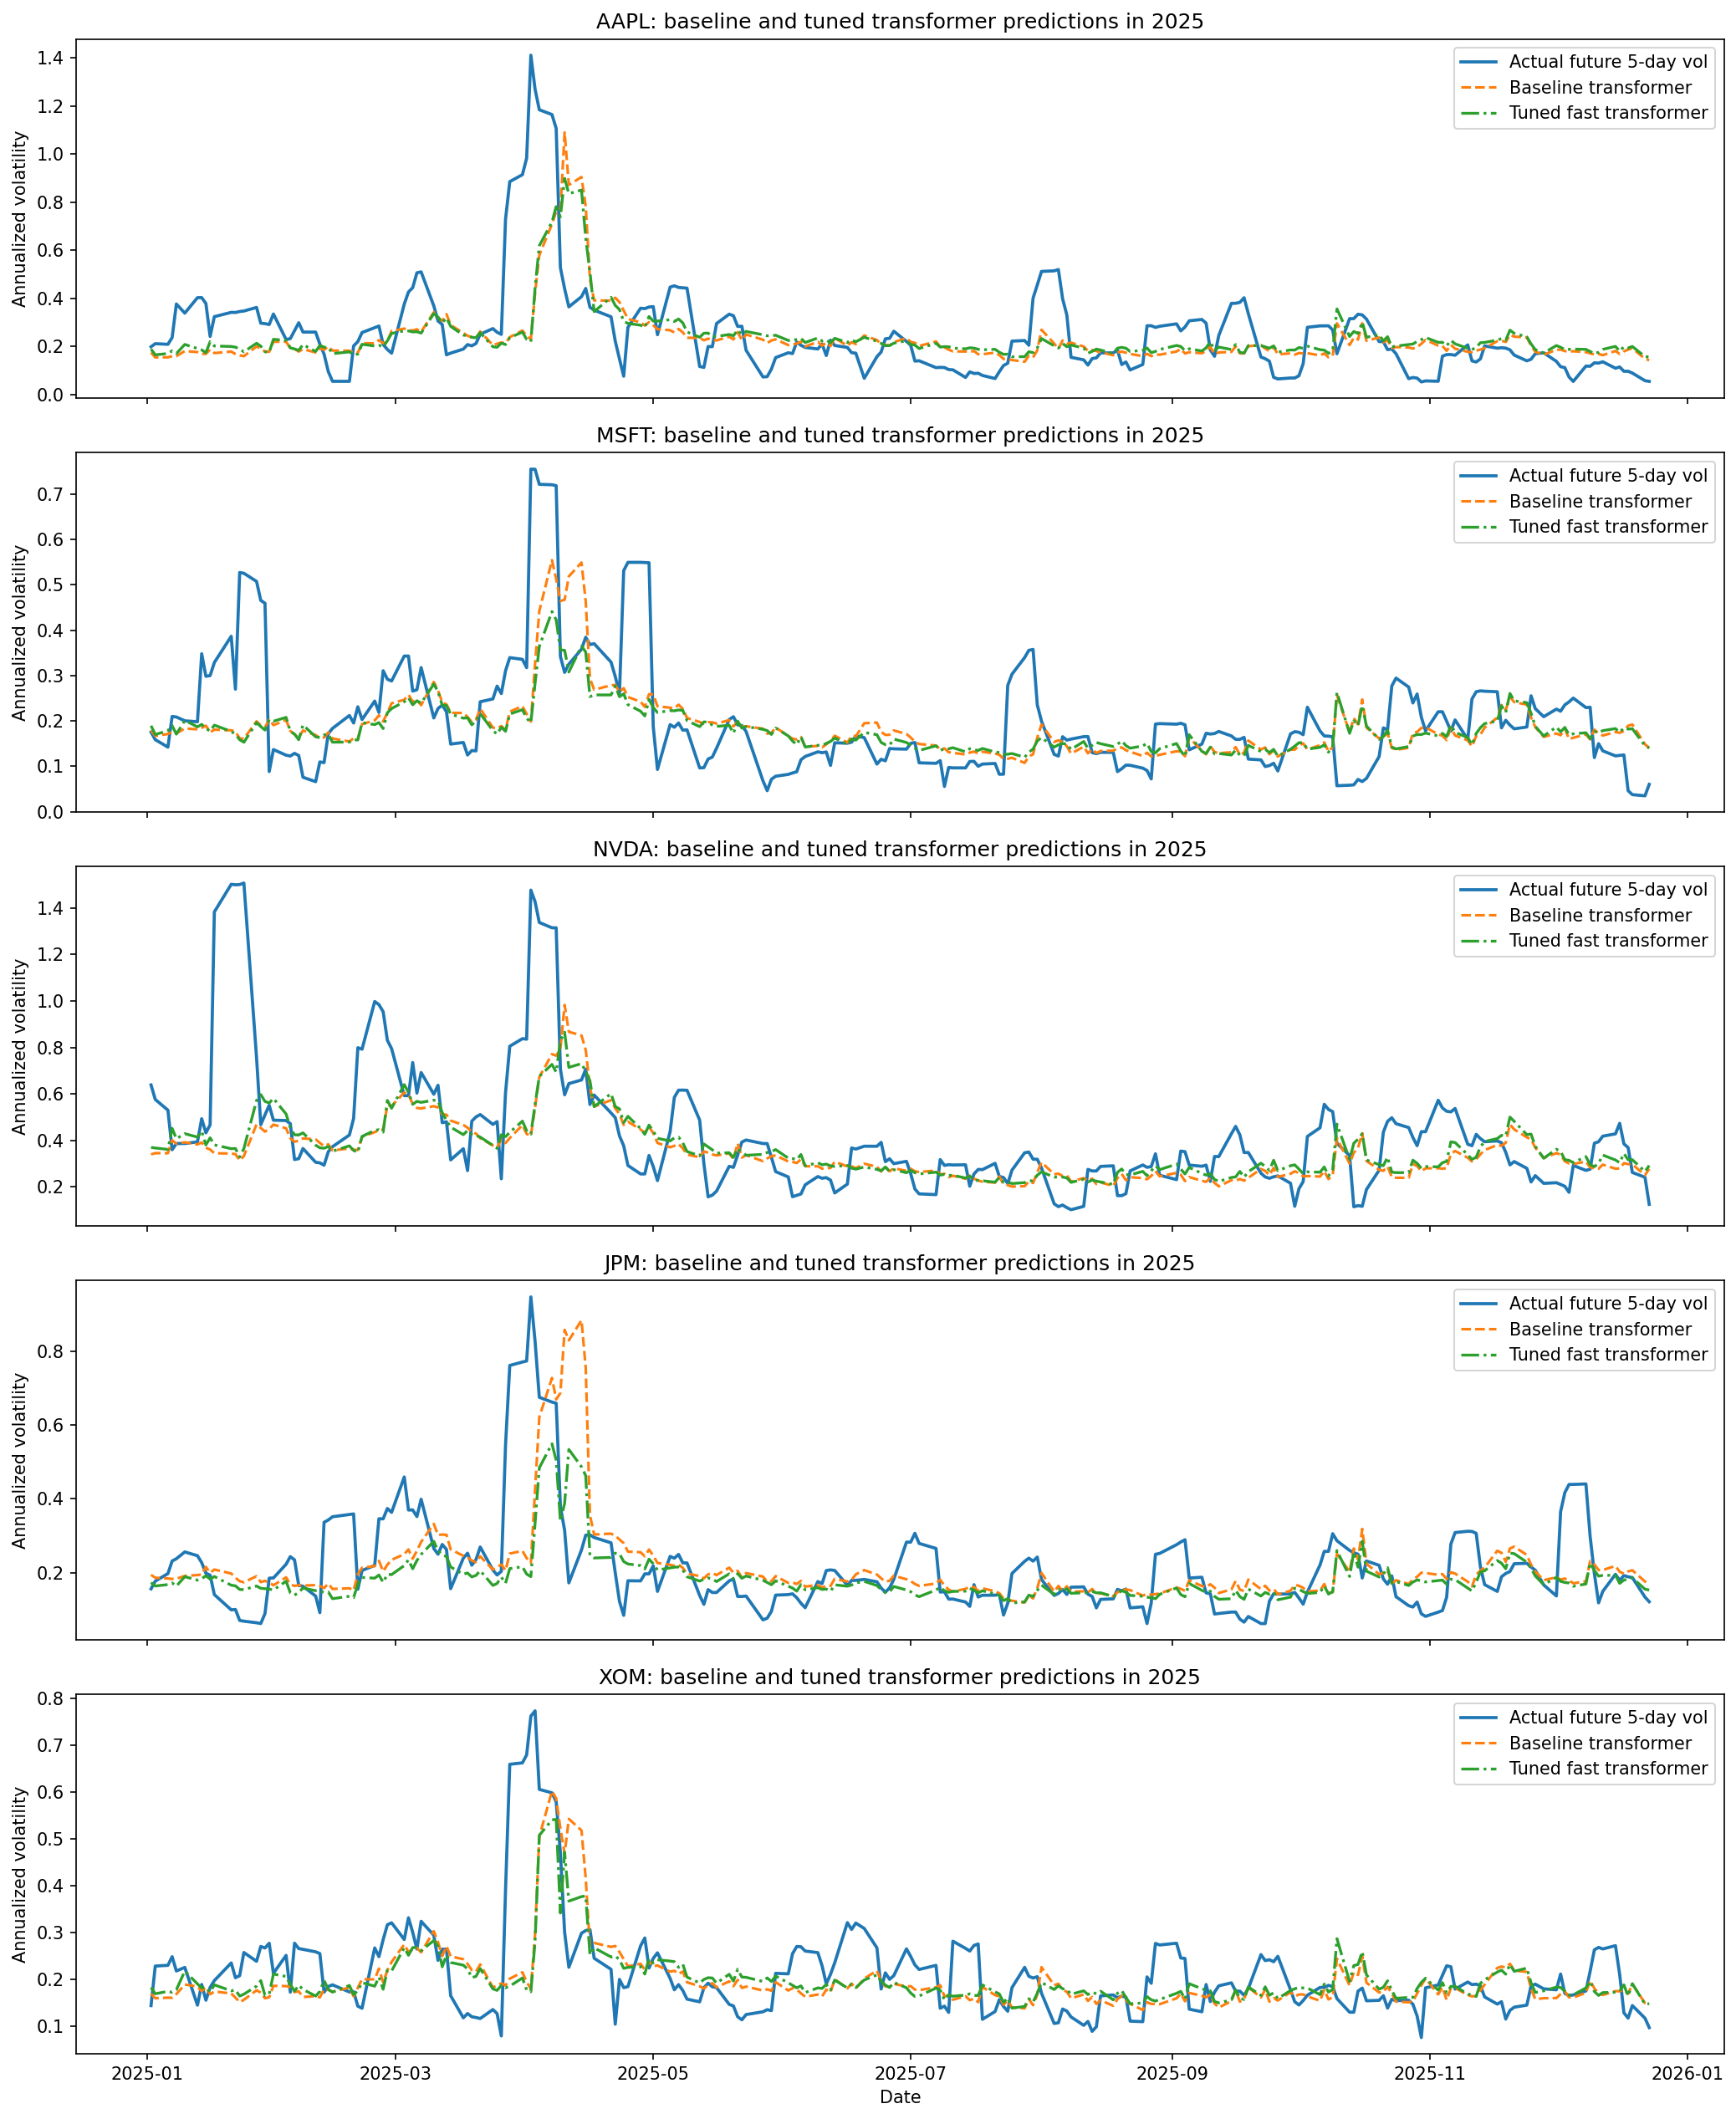

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/04_transformer_baseline_and_tuned_5stocks.png')

In [6]:
baseline_predictions = results['baseline_transformer']['test_predictions']
tuned_predictions = results['tuned_fast_transformer']['test_predictions']

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 17), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    base_plot_df = baseline_predictions[baseline_predictions['Ticker'] == ticker].sort_values('Date')
    tuned_plot_df = tuned_predictions[tuned_predictions['Ticker'] == ticker].sort_values('Date')
    ax.plot(base_plot_df['Date'], base_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(base_plot_df['Date'], base_plot_df['prediction'], label='Baseline transformer', linestyle='--', linewidth=1.5)
    ax.plot(tuned_plot_df['Date'], tuned_plot_df['prediction'], label='Tuned fast transformer', linestyle='-.', linewidth=1.6)
    ax.set_title(f'{ticker}: baseline and tuned transformer predictions in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / '04_transformer_baseline_and_tuned_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path